**OPERASI PADA SINYAL 1D**

**A.1 MEMBUAT SINYAL DISKRIT**

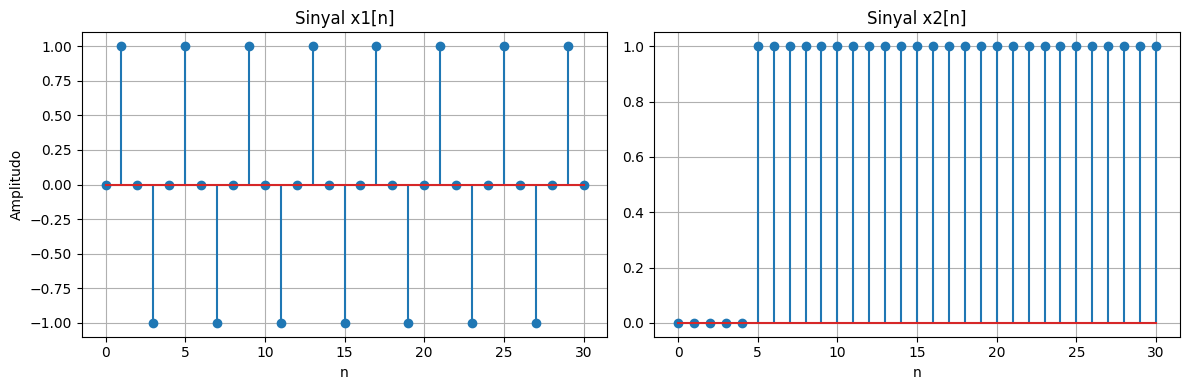

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# n = 0, 1, 2, ..., 30 [cite: 42]
n = np.arange(0, 31)

# Sinyal pertama: x1[n] = sin(0.5 * pi * n) [cite: 37, 38]
x1 = np.sin(0.5 * np.pi * n)

# Sinyal kedua : 0 UNTUK n<5, 1 untuk n>=5 [cite: 39, 40]
x2 = np.where(n < 5, 0, 1)

# Output: Plot sinyal x1[n] dan x2[n] [cite: 43, 44, 45]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n, x1)
plt.title('Sinyal x1[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, x2)
plt.title('Sinyal x2[n]')
plt.xlabel('n')
plt.grid(True)

plt.tight_layout()
plt.show()

**A.2 OPERASI PENJUMLAHAN**

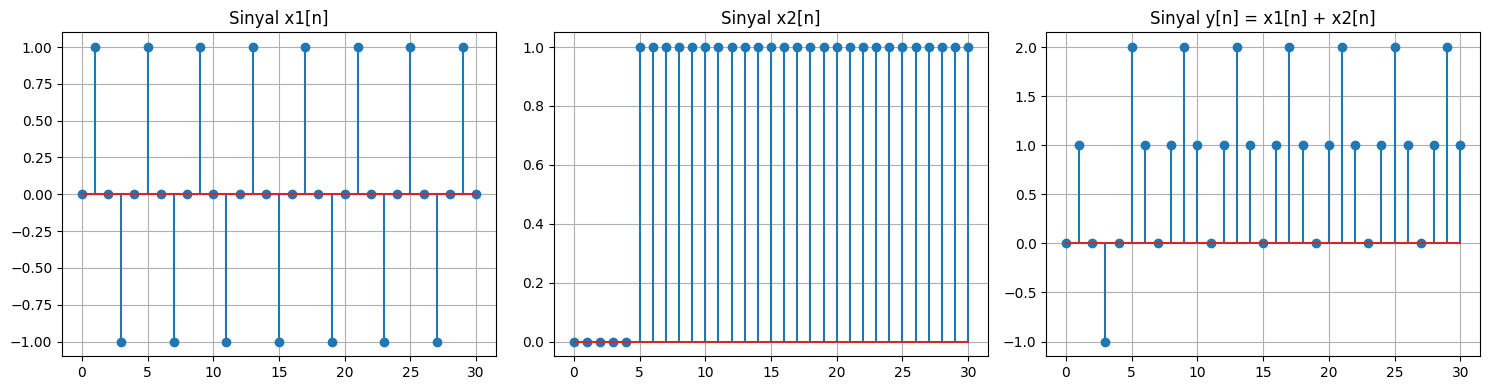

In [2]:
y_tambah = x1 + x2

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.stem(n, x1)
plt.title('Sinyal x1[n]')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n, x2)
plt.title('Sinyal x2[n]')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n, y_tambah)
plt.title('Sinyal y[n] = x1[n] + x2[n]')
plt.grid(True)

plt.tight_layout()
plt.show()

**A.3 OPERASI PENGGESERAN SINYAL**

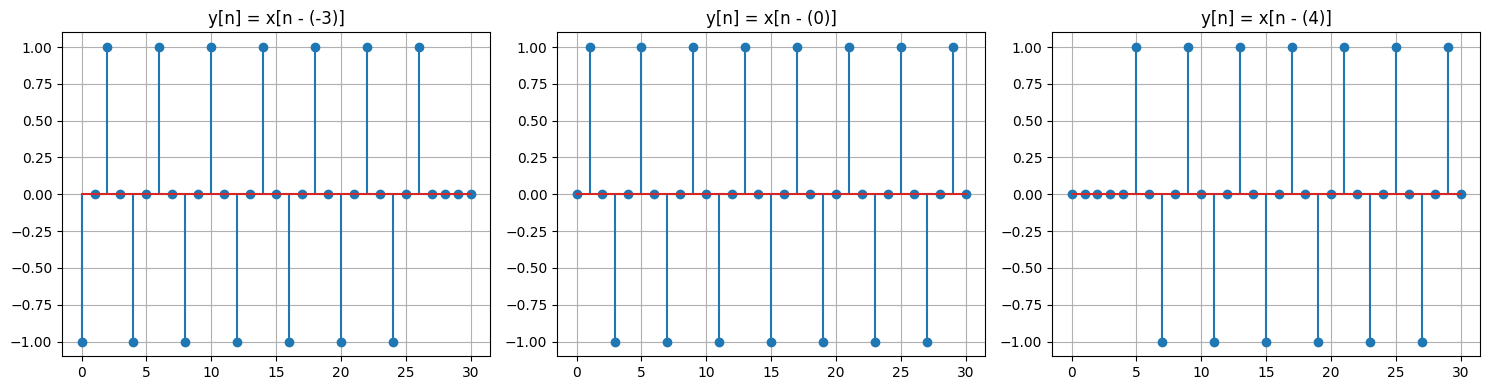

In [3]:
k_values = [-3, 0, 4]

plt.figure(figsize=(15, 4))

for i, k in enumerate(k_values):
    plt.subplot(1, 3, i+1)
    
    # array kosong
    y_geser = np.zeros_like(x1)
    
    # Logic penggeseran
    if k > 0:
        y_geser[k:] = x1[:-k] # ke kanan (delay)
    elif k < 0:
        y_geser[:k] = x1[-k:] # ke kiri (advance)
    else:
        y_geser = x1.copy()   # Tidak digeser
        
    plt.stem(n, y_geser)
    plt.title(f'y[n] = x[n - ({k})]')
    plt.grid(True)

plt.tight_layout()
plt.show()

**A.4 OPERASI AMPLIFIKASI SINYAL**

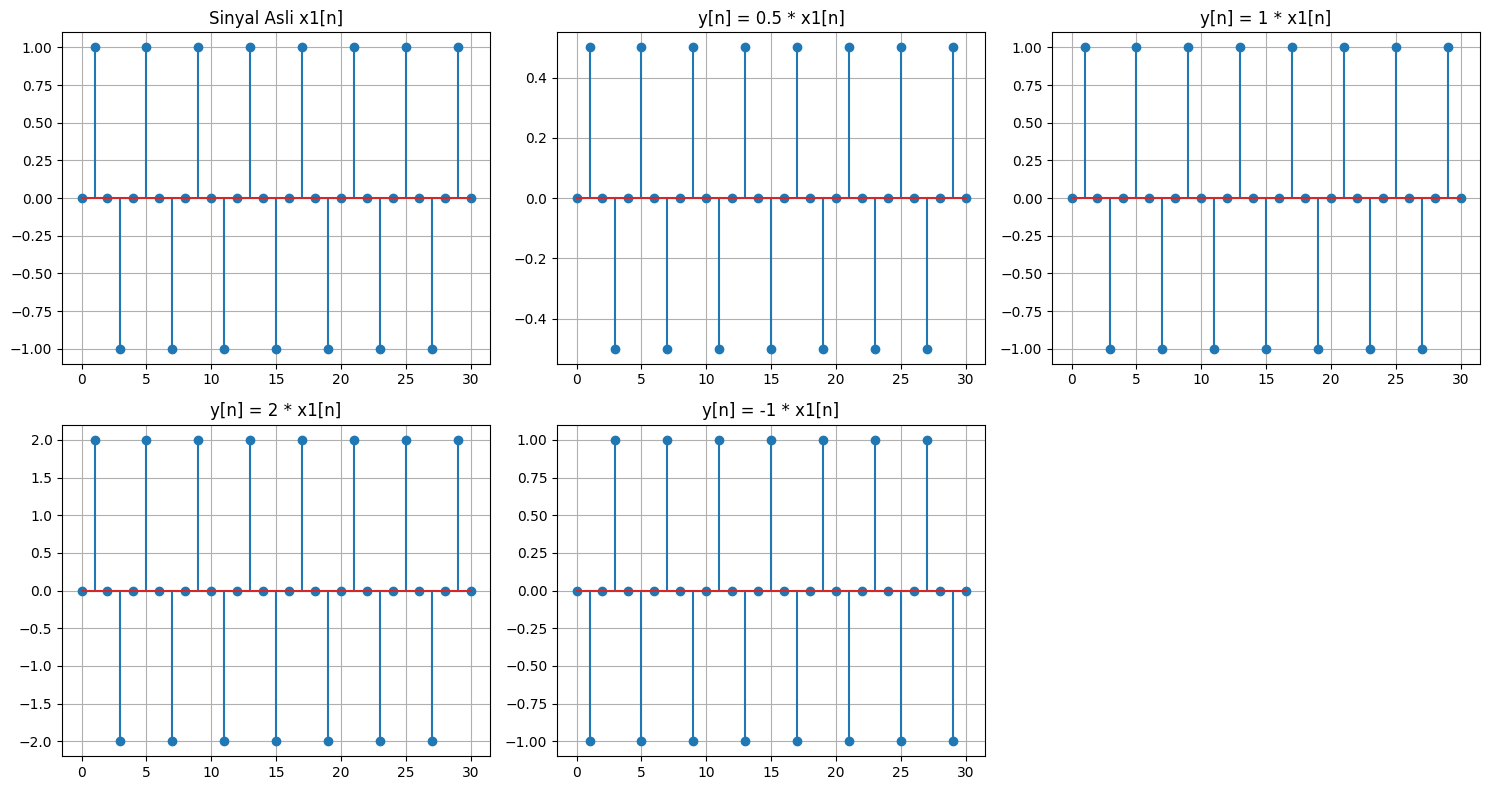

In [4]:
alphas = [0.5, 1, 2, -1]

plt.figure(figsize=(15, 8))

# sinyal asli Jadi referensi
plt.subplot(2, 3, 1)
plt.stem(n, x1)
plt.title('Sinyal Asli x1[n]')
plt.grid(True)

# hasil amplifikasi
for i, alpha in enumerate(alphas):
    y_amp = alpha * x1
    plt.subplot(2, 3, i+2)
    plt.stem(n, y_amp)
    plt.title(f'y[n] = {alpha} * x1[n]')
    plt.grid(True)

plt.tight_layout()
plt.show()

**OPERASI PADA CITRA 2D**

**B.1 MEMBACA DAN MENAMPILKAN CITRA**

In [5]:
import cv2
cv2.imread(r'/kaggle/input/datasets/abroralfarisi/testcitra/freakhulk.png')
cv2.imread(r'/kaggle/input/datasets/abroralfarisi/testcitra/diketawainikn.png')

array([[[ 21,  21,  21],
        [ 72,  66,  64],
        [169, 147, 139],
        ...,
        [235, 203, 188],
        [235, 204, 189],
        [235, 204, 189]],

       [[ 30,  30,  30],
        [225, 194, 183],
        [231, 199, 188],
        ...,
        [235, 203, 188],
        [236, 204, 189],
        [235, 204, 189]],

       [[ 12,  12,  12],
        [232, 200, 189],
        [231, 199, 188],
        ...,
        [236, 203, 188],
        [237, 204, 189],
        [235, 204, 189]],

       ...,

       [[  0,   0,   0],
        [123, 134, 172],
        [124, 135, 173],
        ...,
        [ 15,  59,  80],
        [ 39,  82, 103],
        [ 70, 112, 134]],

       [[  0,   0,   0],
        [130, 139, 176],
        [130, 139, 176],
        ...,
        [ 32,  75,  94],
        [ 56,  98, 117],
        [ 82, 122, 141]],

       [[  1,   1,   1],
        [133, 142, 179],
        [133, 142, 179],
        ...,
        [ 45,  87, 106],
        [ 67, 109, 128],
        [ 89, 128, 148]]

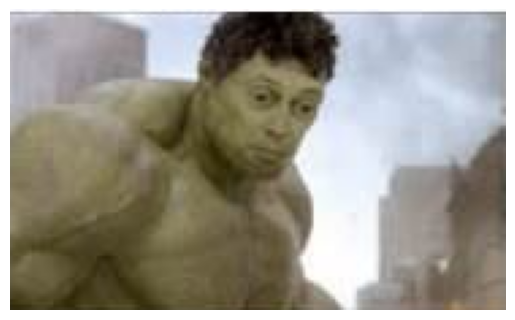

In [6]:
import cv2
import matplotlib.pyplot as plt

# Ganti path di bawah ini dengan hasil print dari langkah 1
path_gambar = '/kaggle/input/folder-dataset-lo/freakhulk.png' 
img = cv2.imread(r'/kaggle/input/datasets/abroralfarisi/testcitra/freakhulk.png')

# OpenCV membaca dalam format BGR, kita ubah ke RGB agar warnanya sesuai
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Menampilkan gambar
plt.imshow(img)
plt.axis('off')
plt.show()

**B.2 OPERASI PENJUMLAHAN CITRA**

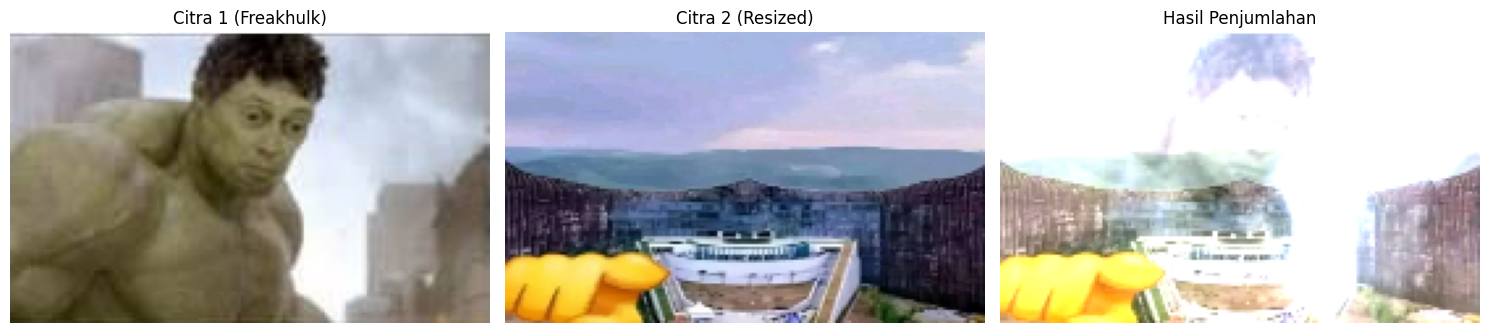

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca kedua citra menggunakan path yang lo kasih
path1 = r'/kaggle/input/datasets/abroralfarisi/testcitra/freakhulk.png'
path2 = r'/kaggle/input/datasets/abroralfarisi/testcitra/diketawainikn.png'

img1 = cv2.imread(path1)
img2 = cv2.imread(path2)

# Mengubah urutan warna dari BGR (OpenCV) menjadi RGB (Matplotlib)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# 2. Proses Resizing
# Kita ambil dimensi tinggi dan lebar dari citra pertama (freakhulk) sebagai patokan
tinggi, lebar = img1.shape[:2]

# Menyamakan ukuran citra kedua (diketawainikn) dengan citra pertama
img2_resized = cv2.resize(img2, (lebar, tinggi))

# 3. Operasi Penjumlahan Citra
# Menggunakan cv2.add agar terhindar dari efek overflow (warna rusak jika piksel > 255)
img_hasil = cv2.add(img1, img2_resized)

# 4. Visualisasi Hasil
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('Citra 1 (Freakhulk)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2_resized)
plt.title('Citra 2 (Resized)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_hasil)
plt.title('Hasil Penjumlahan')
plt.axis('off')

plt.tight_layout()
plt.show()

****B.3 OPERASI PENGGESERAN CITRA****
**B.4 OPERASI AMPLIFIKASI CITRA**

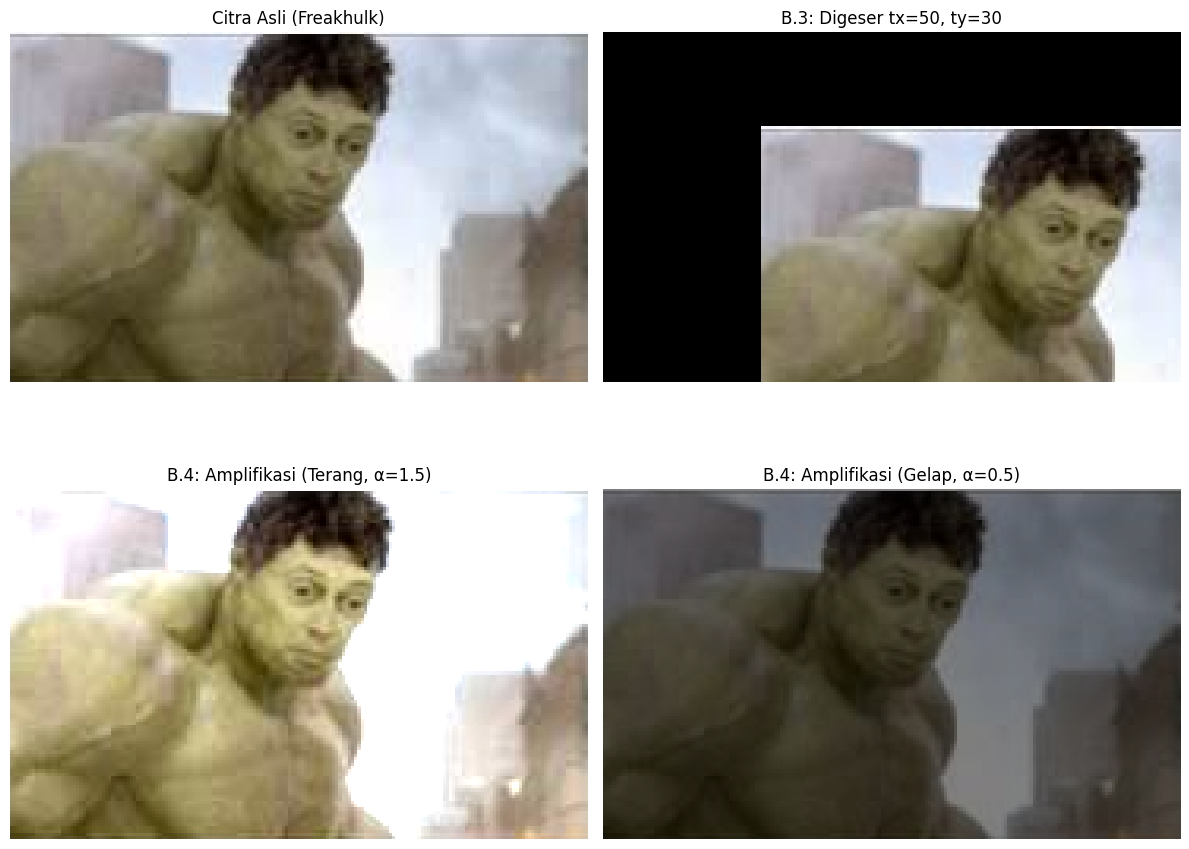

In [8]:
# nilai geser: tx (sumbu x / kanan-kiri), ty (sumbu y / atas-bawah)
tx = 50  # piksel
ty = 30  # piksel

# Membuat matriks transformasi translasi M
M = np.float32([[1, 0, tx], [0, 1, ty]])

# cv2.warpAffine untuk menerapkan pergeseran
img_geser = cv2.warpAffine(img1, M, (img1.shape[1], img1.shape[0]))


# --- B.4 OPERASI AMPLIFIKASI CITRA ---
# Nilai alpha > 1 membuat gambar lebih terang, 0 < alpha < 1 membuat gambar lebih gelap
alpha_terang = 1.5
alpha_gelap = 0.5

# Menggunakan cv2.convertScaleAbs untuk mengalikan matriks citra dengan aman 
# (otomatis melakukan clipping agar nilai tidak lebih dari 255)
img_terang = cv2.convertScaleAbs(img1, alpha=alpha_terang, beta=0)
img_gelap = cv2.convertScaleAbs(img1, alpha=alpha_gelap, beta=0)


# --- VISUALISASI ---
plt.figure(figsize=(12, 10))

# 1. Citra Asli
plt.subplot(2, 2, 1)
plt.imshow(img1)
plt.title('Citra Asli (Freakhulk)')
plt.axis('off')

# 2. Citra Digeser
plt.subplot(2, 2, 2)
plt.imshow(img_geser)
plt.title(f'B.3: Digeser tx={tx}, ty={ty}')
plt.axis('off')

# 3. Citra Terang
plt.subplot(2, 2, 3)
plt.imshow(img_terang)
plt.title(f'B.4: Amplifikasi (Terang, \u03B1={alpha_terang})')
plt.axis('off')

# 4. Citra Gelap
plt.subplot(2, 2, 4)
plt.imshow(img_gelap)
plt.title(f'B.4: Amplifikasi (Gelap, \u03B1={alpha_gelap})')
plt.axis('off')

plt.tight_layout()
plt.show()

**UJI SISTEM LINIER**

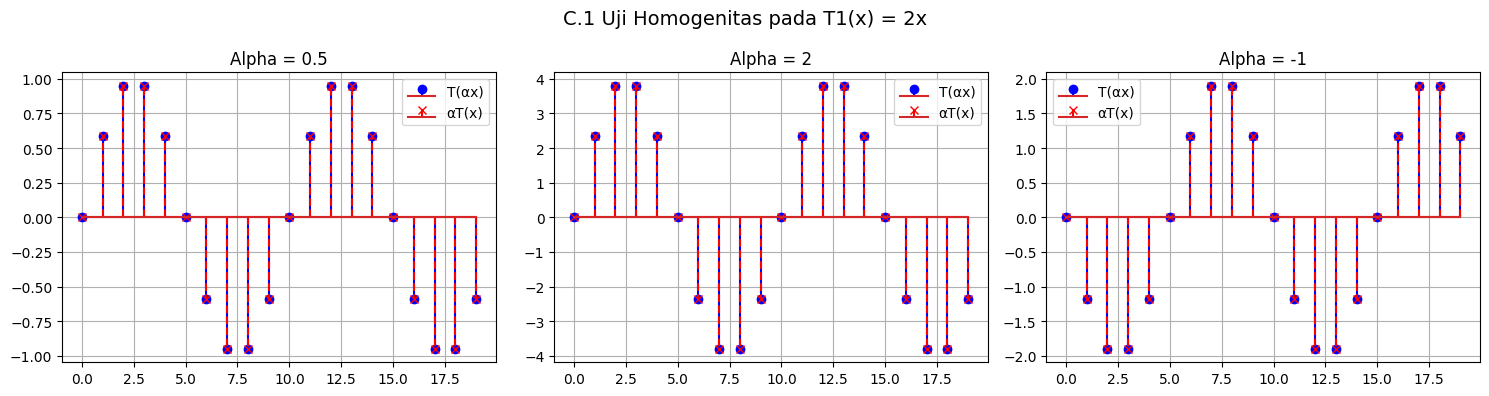

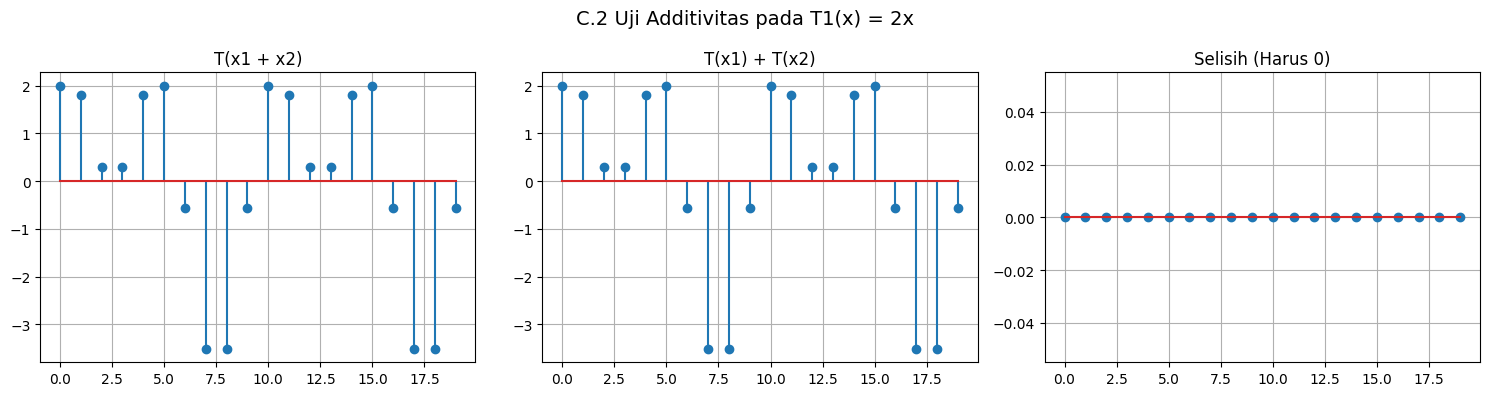

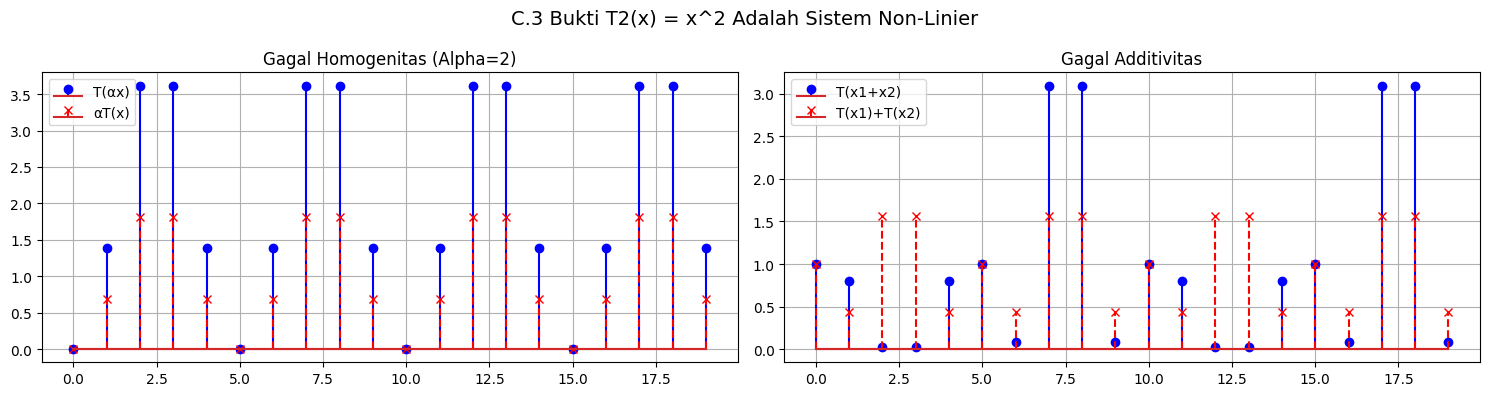

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Mendefinisikan sinyal untuk uji coba
n = np.arange(0, 20)
x1 = np.sin(0.2 * np.pi * n)  # Sinyal 1
x2 = np.cos(0.4 * np.pi * n)  # Sinyal 2

# Mendefinisikan kedua sistem 
def T1(x):
    return 2 * x  # (T1(x) = 2x)

def T2(x):
    return x**2   # (T2(x) = x^2)

# ==========================================
# C.1 UJI HOMOGENITAS PADA T1(x) = 2x
# ==========================================
alphas = [0.5, 2, -1] # 3 nilai alpha 
plt.figure(figsize=(15, 4))
plt.suptitle('C.1 Uji Homogenitas pada T1(x) = 2x', fontsize=14)

for i, alpha in enumerate(alphas):
    # 1. T(alpha * x)
    hasil_kiri = T1(alpha * x1)
    # 2. alpha * T(x)
    hasil_kanan = alpha * T1(x1)
    
    plt.subplot(1, 3, i+1)
    plt.stem(n, hasil_kiri, linefmt='b-', markerfmt='bo', label='T(αx)')
    # Menggunakan marker 'x' warna merah untuk hasil kanan agar terlihat tumpang tindihnya
    plt.stem(n, hasil_kanan, linefmt='r--', markerfmt='rx', label='αT(x)')
    plt.title(f'Alpha = {alpha}')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# C.2 UJI ADDITIVITAS PADA T1(x) = 2x
# ==========================================
hasil_tambah_dulu = T1(x1 + x2)       # T(x1 + x2)
hasil_proses_dulu = T1(x1) + T1(x2)   # T(x1) + T(x2)
selisih = hasil_tambah_dulu - hasil_proses_dulu # Selisih

plt.figure(figsize=(15, 4))
plt.suptitle('C.2 Uji Additivitas pada T1(x) = 2x', fontsize=14)

plt.subplot(1, 3, 1)
plt.stem(n, hasil_tambah_dulu)
plt.title('T(x1 + x2)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n, hasil_proses_dulu)
plt.title('T(x1) + T(x2)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n, selisih)
plt.title('Selisih (Harus 0)')
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# C.3 UJI SISTEM NON-LINIER T2(x) = x^2
# ==========================================
# Uji Homogenitas (Alpha = 2)
alpha_test = 2
homo_kiri_T2 = T2(alpha_test * x1)
homo_kanan_T2 = alpha_test * T2(x1)

# Uji Additivitas
add_kiri_T2 = T2(x1 + x2)
add_kanan_T2 = T2(x1) + T2(x2)

plt.figure(figsize=(15, 4))
plt.suptitle('C.3 Bukti T2(x) = x^2 Adalah Sistem Non-Linier', fontsize=14)

plt.subplot(1, 2, 1)
plt.stem(n, homo_kiri_T2, linefmt='b-', markerfmt='bo', label='T(αx)')
plt.stem(n, homo_kanan_T2, linefmt='r--', markerfmt='rx', label='αT(x)')
plt.title(f'Gagal Homogenitas (Alpha={alpha_test})')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, add_kiri_T2, linefmt='b-', markerfmt='bo', label='T(x1+x2)')
plt.stem(n, add_kanan_T2, linefmt='r--', markerfmt='rx', label='T(x1)+T(x2)')
plt.title('Gagal Additivitas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()